run 
```
ti cache clean
python MLUPS_test.py > log_file_name.log
```

In this notebook you can analyse the log file. 

In [205]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [206]:
def real_time_threshold(nLattice,dt):
    return nLattice/dt/1e6

In [207]:
def parse_log_v1(log_file):
    n_lattice_list = []
    macro_MLUPS_list = [] # 总计算量/总时间
    init_time_list = []
    compile_time_list = []
    avg_MLUPS_list = [] # 每次计算量/每次时间 mean
    std_MLUPS_list = [] # 每次计算量/每次时间 std
    with open(log_file, 'r',encoding='utf-8') as f:
        line = f.readline() # 第一行忽略
        line = f.readline()
        while line: 
            line2 = f.readline() # n lattice
            line3 = f.readline() # MLUPS
            line4 = f.readline() # avg time
            line5 = f.readline() # compile time
            line6 = f.readline() # init time
            line7 = f.readline() # v test
            line8 = f.readline() # execution time list
            line9 = f.readline() # -----
            line = f.readline() # EOF or next arch
            nLattice = int(line2)
            n_lattice_list.append(nLattice)
            macro_MLUPS_list.append(float(line3))
            compile_time_list.append(float(line5))
            init_time_list.append(float(line6))
            exec_time_list = [float(t) for t in line8[1:-2].split(',') if t.strip()!='']
            exec_time_array = np.array(exec_time_list)
            MLUPS_array = nLattice*10000 / (exec_time_array * 1e6)
            avg_MLUPS_list.append(np.mean(MLUPS_array))
            std_MLUPS_list.append(np.std(MLUPS_array))
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

In [208]:
def parse_log_v2(log_file):
    n_lattice_list = []
    avg_MLUPS_list = []
    std_MLUPS_list = []
    init_time_list = []
    compile_time_list = []
    with open(log_file, 'r') as f:
        line = f.readline() # 第一行忽略
        line = f.readline()
        while not line.startswith("[Taichi]"):
            line = f.readline()    # skip skipping
        while line: 
            line2 = f.readline() # n lattice
            if line2.startswith("Already"):
                line = f.readline()
            elif  line2.startswith("[Taichi]"):
                continue
            else:
                line3 = f.readline() # avg MLUPS
                line4 = f.readline() # std MLUPS
                line5 = f.readline() # compile time
                line6 = f.readline() # init time
                line8 = f.readline() # execution time list
                line9 = f.readline() # -----
                line = f.readline() # EOF or next arch
                try:
                    nLattice = int(line2.split(":")[1].strip())
                    n_lattice_list.append(nLattice)
                    compile_time_list.append(float(line5.split(":")[1].strip()))
                    init_time_list.append(float(line6.split(":")[1].strip()))
                    # exec_time_list = [float(t) for t in line8.split(':')[1] if t.strip()!='']
                    avg_MLUPS_list.append(float(line3.split(":")[1].strip()))
                    std_MLUPS_list.append(float(line4.split(":")[1].strip()))
                except: # invalid ending due to interruption
                    print("wrong file line",line2)
                    pass
        index = np.argsort(n_lattice_list)
        n_lattice_list = np.array(n_lattice_list)[index].tolist()
        avg_MLUPS_list = np.array(avg_MLUPS_list)[index].tolist()
        std_MLUPS_list = np.array(std_MLUPS_list)[index].tolist()
        compile_time_list = np.array(compile_time_list)[index].tolist()
        init_time_list = np.array(init_time_list)[index].tolist()
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

wrong file line 

wrong file line 



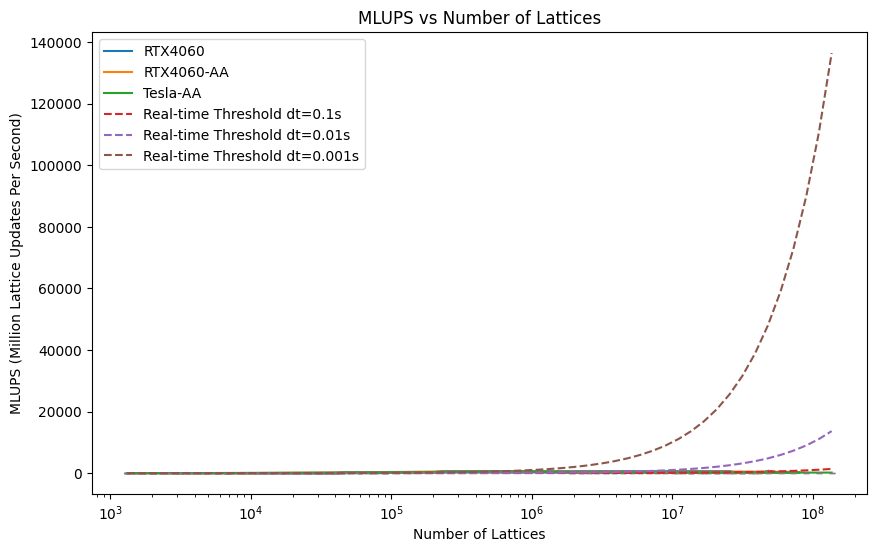

In [ ]:
log_file = "log/labComputer_hongxuan_0112_utf8.log" # log file path
# log_file = "log/YZS_PC_vulkan_MLUPS.log" # log file path
log_files = [
    # "log/labComputer_hongxuan_0112_utf8.log",
                # "log/YZS_PC_vulkan_MLUPS.log",
                # "log/YZS_laptop_cpu_MLUPS.log",
                "log/YZS_legion_cuda_all.log",
                "log/YZS_legion_cuda_AA_all.log",
                "log/Tesla_MLUPS_AA.log"
                ] # log file path list
arch_name = [
    # "RTX3090",
    # "vulkan",
    # "intel",
    "RTX4060",
    "RTX4060-AA",
    "Tesla-AA"
    ] # arch name list corresponding to log file list
plt.figure(figsize=(10,6))
for i in range(len(log_files)):
    n_lattice_list,  avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list = parse_log_v2(log_files[i])
    plt.plot(n_lattice_list, avg_MLUPS_list, '-', label=arch_name[i])
    plt.errorbar(n_lattice_list, avg_MLUPS_list, yerr=std_MLUPS_list, fmt='none', ecolor='gray', capsize=2)
MLUPS_threshold_list_1 = [real_time_threshold(nLattice,dt=0.1) for nLattice in n_lattice_list]
MLUPS_threshold_list_2 = [real_time_threshold(nLattice,dt=0.01) for nLattice in n_lattice_list]
MLUPS_threshold_list_3 = [real_time_threshold(nLattice,dt=0.001) for nLattice in n_lattice_list]

plt.plot(n_lattice_list, MLUPS_threshold_list_1, '--', label='Real-time Threshold dt=0.1s')
plt.plot(n_lattice_list, MLUPS_threshold_list_2, '--', label='Real-time Threshold dt=0.01s')
plt.plot(n_lattice_list, MLUPS_threshold_list_3, '--', label='Real-time Threshold dt=0.001s')
plt.ylim(0, 1000)
plt.xscale('log')
# plt.xlim(0.5e6,4e6)
plt.xlabel('Number of Lattices')
plt.ylabel(f'MLUPS (Million Lattice Updates Per Second)')
plt.title(f"MLUPS vs Number of Lattices")
plt.legend()
plt.show()

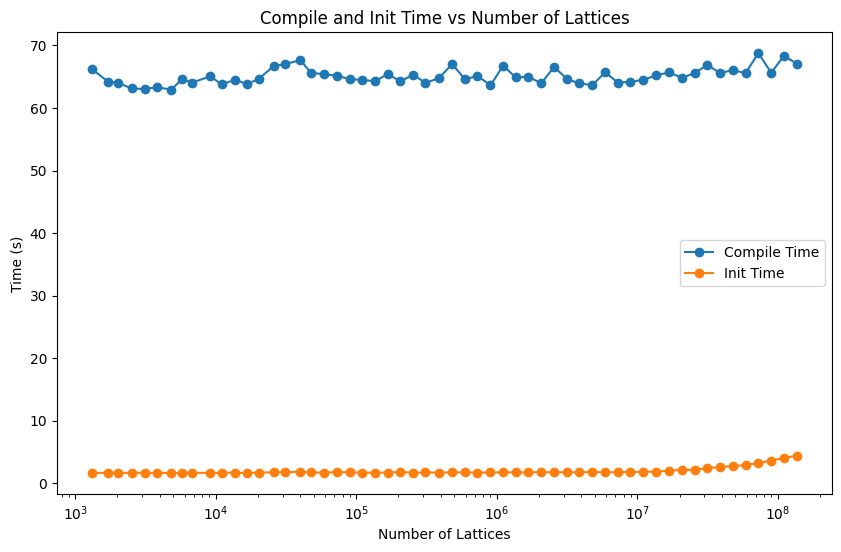

In [210]:
plt.figure(figsize=(10,6))
plt.plot(n_lattice_list, compile_time_list, 'o-', label='Compile Time')
plt.plot(n_lattice_list, init_time_list, 'o-', label='Init Time')
plt.xlabel('Number of Lattices')
plt.ylabel('Time (s)')
plt.title('Compile and Init Time vs Number of Lattices')
plt.legend()
plt.xscale('log')
plt.show()